In [1]:
import pandas as pd
import numpy as np
import sys
import os
notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..'))
project_path = os.path.abspath(os.path.join(src_path, '..'))
sys.path.append(src_path)
sys.path.append(project_path)
from src.database import DatabaseManager
db = DatabaseManager()

In [2]:
query = 'SELECT * FROM match_details'
matches = db.select_to_df(query)
query = 'SELECT * FROM patches'
patches = db.select_to_df(query)

In [3]:
from sklearn.preprocessing import PowerTransformer
df = matches
df_full = df.dropna(subset=['avg_radiant_rating', 'avg_dire_rating', 'radiant_draft_score', 'dire_draft_score', 'gameVersionId'], axis=0).copy()

df_train = df_full[df_full['gameVersionId'] <= 178].copy()
df_test = df_full[df_full['gameVersionId'] > 178].copy()

pt_rating = PowerTransformer()
pt_draft = PowerTransformer()

df_train['rating_diff'] = pt_rating.fit_transform(pd.DataFrame(df_train['avg_radiant_rating'] - df_train['avg_dire_rating']))
df_train['draft_diff'] = pt_draft.fit_transform(pd.DataFrame(df_train['radiant_draft_score'] - df_train['dire_draft_score']))

df_test['rating_diff'] = pt_rating.transform(pd.DataFrame(df_test['avg_radiant_rating'] - df_test['avg_dire_rating']))
df_test['draft_diff'] = pt_draft.transform(pd.DataFrame(df_test['radiant_draft_score'] - df_test['dire_draft_score']))

In [4]:
X_train = df_train[['rating_diff', 'draft_diff']].values
X_test = df_test[['rating_diff', 'draft_diff']].values
y_train = df_train['didRadiantWin'].astype('int').values
y_test = df_test['didRadiantWin'].astype('int').values

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
log_reg_pipeline = Pipeline([
    ('model', LogisticRegression())
])
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=True

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
log_reg_pipeline = Pipeline([
    ('model', LogisticRegression(C=0.001))
])
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=Tr

rating_diff    0.515332
draft_diff     2.152005
dtype: float64
Test set accuracy: 0.7101045692202773
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     16807
           1       0.73      0.72      0.72     18385

    accuracy                           0.71     35192
   macro avg       0.71      0.71      0.71     35192
weighted avg       0.71      0.71      0.71     35192



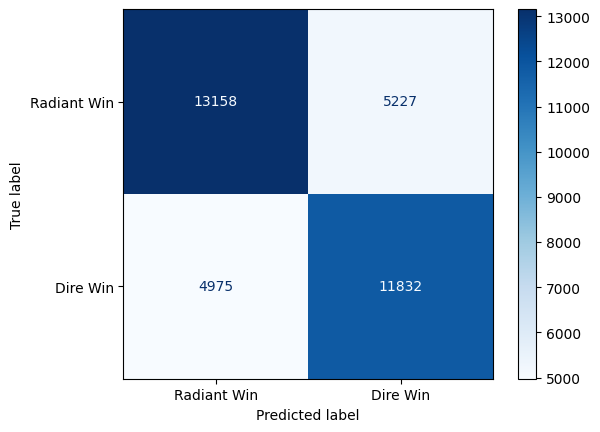

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = log_reg_pipeline.predict(X_test)
feature_names = ['rating_diff', 'draft_diff']
# feature_names = ['draft_diff']
coefs = log_reg_pipeline.named_steps['model'].coef_[0]
coef_series = pd.Series(coefs, index=feature_names)
print(coef_series)
print(f'Test set accuracy: {accuracy_score(y_test, y_pred)}')
print(f'{classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Radiant Win', 'Dire Win'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=0.01))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline_cv, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

Cross-validation accuracies: [0.82444235 0.82659625 0.82251925 0.82594199 0.82482075]
Mean CV Accuracy: 0.8249 (± 0.0014)


In [13]:
os.getcwd()
project_path

'c:\\Users\\benib\\Projects\\Dota'

In [16]:
import joblib
joblib.dump(log_reg_pipeline, f'{project_path}/src/ml_models/log_reg_model.joblib')

['c:\\Users\\benib\\Projects\\Dota/src/ml_models/log_reg_model.joblib']

In [ ]:
X_train = df_train['draft_diff'].values.reshape(-1, 1)
X_test = df_test['draft_diff'].values.reshape(-1, 1)